In [1]:
import matplotlib
import sys

sys.path.append("/kaggle/input/models/minhkhanhdoan/deepland-mid-32/pytorch/default/1")

In [2]:
import torch
import math
import torch.nn as nn
import torch.nn.functional as F

class Flatten(nn.Module):
    def forward(self, x):
        return x.view(x.size(0), -1)

class ChannelGate(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16):
        super(ChannelGate, self).__init__()
        # if gate_channels // reduction_ratio == 0: #fixed for mobileNetV2
        #     reduction_ratio = gate_channels
        self.mlp = nn.Sequential(
            Flatten(),
            nn.Linear(gate_channels, gate_channels // reduction_ratio),
            nn.ReLU(),
            nn.Linear(gate_channels // reduction_ratio, gate_channels)
            )
    def forward(self, x):
        squeeze_avg = F.avg_pool2d( x, (x.size(2), x.size(3)), stride=(x.size(2), x.size(3)))
        channel_att = self.mlp(squeeze_avg)
        scale = torch.sigmoid(channel_att).unsqueeze(2).unsqueeze(3).expand_as(x)
        return x * scale

class SE(nn.Module):
    def __init__(self, gate_channels, reduction_ratio=16):
        super(SE, self).__init__()
        self.ChannelGate = ChannelGate(gate_channels, reduction_ratio)
    def forward(self, x):
        x_out = self.ChannelGate(x)
        return x_out

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PDPBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride):
        super().__init__()
        self.stride = stride

        # ── Pointwise 1 ──
        self.pw1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=in_channels,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(num_features=in_channels)

        # ── Depthwise 1 ──
        self.dw1 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=in_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            dilation=1,
            groups=in_channels,
            bias=False
        )
        self.bn_dw1 = nn.BatchNorm2d(num_features=in_channels)

        # ── Depthwise 2 (dilation=2) ──
        self.dw2 = nn.Conv2d(
            in_channels=in_channels,
            out_channels=in_channels,
            kernel_size=3,
            stride=1,
            padding=2,
            dilation=2,
            groups=in_channels,
            bias=False
        )
        self.bn_dw2 = nn.BatchNorm2d(num_features=in_channels)

        # ── Pointwise 2 ──
        self.pw2 = nn.Conv2d(
            in_channels=2 * in_channels,
            out_channels=out_channels,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(num_features=out_channels)

        self.se = SE(out_channels,4)

        # ── Shortcut ──
        if stride != 1 or in_channels != out_channels:
            self.shortcut_conv = nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=1,
                stride=stride,
                padding=0,
                bias=False
            )
            self.shortcut_bn = nn.BatchNorm2d(num_features=out_channels)
        else:
            self.shortcut_conv = None

        self.act = nn.SiLU(inplace=True)

    def shuffle(self, x):
        b, c, h, w = x.size()
        groups = 2

        x = x.view(b, groups, c // groups, h, w)
        x = x.transpose(1, 2).contiguous()

        return x.view(b, c, h, w)

    def forward(self, x):
        identity = x

        # PW1
        x1 = self.act(self.bn1(self.pw1(x)))

        # DW branches
        d1 = self.act(self.bn_dw1(self.dw1(x1)))
        d2 = self.act(self.bn_dw2(self.dw2(x1)))

        if self.stride == 2:
            d2 = F.avg_pool2d(
                input=d2,
                kernel_size=2,
                stride=2,
                padding=0
            )

        out = torch.cat([d1, d2], dim=1)
        out = self.shuffle(out)

        # PW2 + SE
        out = self.bn2(self.pw2(out))
        out = self.se(out)

        # Shortcut
        if self.shortcut_conv is not None:
            identity = self.shortcut_bn(self.shortcut_conv(identity))

        out = out + identity
        out = self.act(out)

        return out

class NetMid(nn.Module):
    def __init__(self, image_size, n_class=10):
        super().__init__()

        small_input = image_size <= 64

        stem_stride = 1 if small_input else 2
        block3_stride = 1 if small_input else 2
        block8_stride = 1 if small_input else 2
        block10_stride = 1 if small_input else 2

        # ── Stem ──
        self.conv1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3,
            stride=stem_stride,
            padding=1,
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(num_features=32)

        # ── Blocks ──
        self.block1 = PDPBlock(in_channels=32, out_channels=64, stride=1)
        self.block2 = PDPBlock(in_channels=64, out_channels=64, stride=1)
        self.block3 = PDPBlock(in_channels=64, out_channels=128, stride=block3_stride)
        self.block5 = PDPBlock(in_channels=128, out_channels=128, stride=1)
        self.block6 = PDPBlock(in_channels=128, out_channels=256, stride=2)
        self.block7 = PDPBlock(in_channels=256, out_channels=256, stride=1)
        self.block8 = PDPBlock(in_channels=256, out_channels=256, stride=block8_stride)
        self.block9 = PDPBlock(in_channels=256, out_channels=512, stride=1)
        self.block10 = PDPBlock(in_channels=512, out_channels=512, stride=block10_stride)

        # ── Head ──
        self.conv2 = nn.Conv2d(
            in_channels=512,
            out_channels=1024,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(num_features=1024)

        self.avgpool = nn.AdaptiveAvgPool2d(output_size=1)

        drop_rate = 0.35 if small_input else 0.4
        self.dropout1 = nn.Dropout(p=drop_rate)

        self.fc1 = nn.Linear(
            in_features=1024,
            out_features=512,
            bias=False
        )
        self.bn_fc = nn.BatchNorm1d(num_features=512)

        self.dropout2 = nn.Dropout(p=drop_rate * 0.5)

        self.fc2 = nn.Linear(
            in_features=512,
            out_features=n_class,
            bias=True
        )

        self.act = nn.SiLU(inplace=True)

    def forward(self, x):
        x = self.act(self.bn1(self.conv1(x)))

        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block5(x)
        x = self.block6(x)
        x = self.block7(x)
        x = self.block8(x)
        x = self.block9(x)
        x = self.block10(x)

        x = self.act(self.bn2(self.conv2(x)))
        x = self.avgpool(x)

        x = x.view(x.size(0), -1)

        x = self.dropout1(x)
        x = self.act(self.bn_fc(self.fc1(x)))
        x = self.dropout2(x)

        x = self.fc2(x)

        return x
net = NetMid(image_size =32, n_class=5)
net.to("cuda")
from torchsummary import summary
print(net)
summary(net, (3,32,32), device="cuda")

NetMid(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): PDPBlock(
    (pw1): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dw1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
    (bn_dw1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (dw2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2), groups=32, bias=False)
    (bn_dw2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pw2): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (se): SE(
      (ChannelGate): ChannelGate(
        (mlp

In [4]:
import json
import os
import random
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler

from datasets_32 import get_dataloaders
# from model_defs import NetMid
from train_config import MID_CONFIG
from train_utils import save_history_csv, save_plots


def set_seed(seed=42):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def run_one_epoch(model, loader, criterion, optimizer, device, scaler, is_train):
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            with autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            with torch.no_grad():
                with autocast("cuda"):
                    outputs = model(images)
                    loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, 100.0 * correct / total


def train():
    cfg = MID_CONFIG

    data_root = "/kaggle/input/datasets/minhkhanhdoan/dataset-deepland/datasets"  # sửa lại
    output_root = "/kaggle/working"

    set_seed(cfg["seed"])
    os.makedirs(output_root, exist_ok=True)

    device = torch.device("cuda")
    torch.backends.cudnn.benchmark = True

    print("Loading data...")
    train_loader, test_loader, class_names = get_dataloaders(
        data_root=data_root,
        image_size=32,
        batch_size=16,
        num_workers=4,
        seed=cfg["seed"],
        print_summary=False,
    )

    print("Data ready")

    n_class = len(class_names)
    model = NetMid(image_size=32, n_class=5).to(device)
    model = torch.compile(model)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg["epochs"])
    scaler = GradScaler("cuda")

    best_acc = 0.0
    best_epoch = 0
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    best = {"epoch": 0, "test_acc": 0.0}

    for epoch in range(1, cfg["epochs"] + 1):
        t0 = time.time()
    
        train_loss, train_acc = run_one_epoch(
            model, train_loader, criterion, optimizer, device, scaler, True
        )
        test_loss, test_acc = run_one_epoch(
            model, test_loader, criterion, optimizer, device, scaler, False
        )
        scheduler.step()
    
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
    
        print(
            f"Epoch [{epoch}/{cfg['epochs']}] "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Test Acc: {test_acc:.2f}%"
        )
    
        save_history_csv(history, f"{output_root}/history.csv")
    
        # ===== BEST =====
        if test_acc > best["test_acc"]:
            best = {"epoch": epoch, "test_acc": test_acc}
            print(f"[BEST] Epoch {epoch} | Acc: {test_acc:.2f}%")
    
            torch.save(model.state_dict(), f"{output_root}/best.pth")
    
    print("BEST:", best)


train()

Loading data...
Data ready


W0408 16:46:02.782000 24 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Epoch [1/100] Train Loss: 1.4164 | Train Acc: 38.40% | Test Acc: 31.20%
[BEST] Epoch 1 | Acc: 31.20%
Epoch [2/100] Train Loss: 1.2273 | Train Acc: 47.24% | Test Acc: 38.40%
[BEST] Epoch 2 | Acc: 38.40%
Epoch [3/100] Train Loss: 1.1498 | Train Acc: 52.56% | Test Acc: 41.60%
[BEST] Epoch 3 | Acc: 41.60%
Epoch [4/100] Train Loss: 1.0501 | Train Acc: 55.64% | Test Acc: 39.60%
Epoch [5/100] Train Loss: 1.0440 | Train Acc: 56.36% | Test Acc: 47.60%
[BEST] Epoch 5 | Acc: 47.60%
Epoch [6/100] Train Loss: 0.9478 | Train Acc: 61.20% | Test Acc: 51.20%
[BEST] Epoch 6 | Acc: 51.20%
Epoch [7/100] Train Loss: 0.9108 | Train Acc: 62.48% | Test Acc: 50.00%
Epoch [8/100] Train Loss: 0.8723 | Train Acc: 65.72% | Test Acc: 52.00%
[BEST] Epoch 8 | Acc: 52.00%
Epoch [9/100] Train Loss: 0.8407 | Train Acc: 66.68% | Test Acc: 50.80%
Epoch [10/100] Train Loss: 0.7889 | Train Acc: 68.64% | Test Acc: 49.20%
Epoch [11/100] Train Loss: 0.7507 | Train Acc: 70.92% | Test Acc: 52.40%
[BEST] Epoch 11 | Acc: 52.40%
Ep

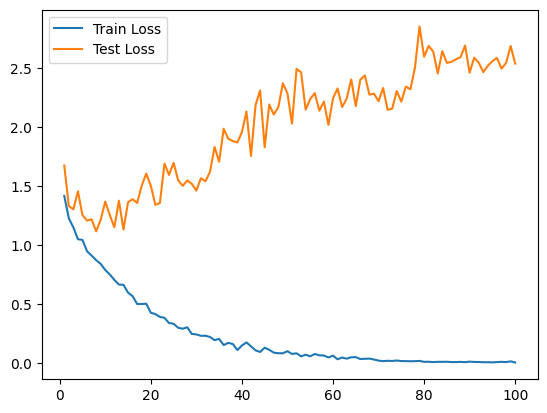

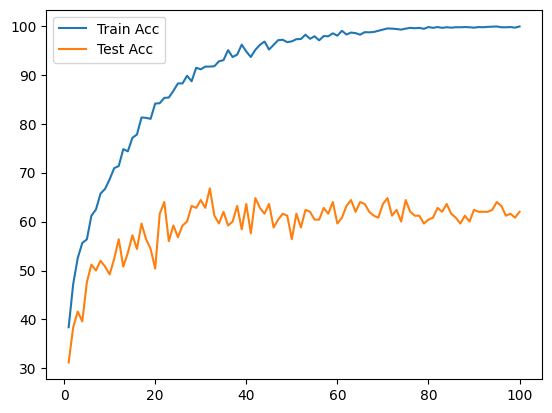

In [5]:
import pandas as pd

df = pd.read_csv("/kaggle/working/history.csv")

history = {
    "train_loss": df["train_loss"].tolist(),
    "test_loss": df["test_loss"].tolist(),
    "train_acc": df["train_acc"].tolist(),
    "test_acc": df["test_acc"].tolist(),
}
# def plot_history(csv_path):
#     import pandas as pd
#     df = pd.read_csv(csv_path)

#     epochs = range(1, len(df) + 1)

#     plt.figure()
#     plt.plot(epochs, df["train_loss"], label="Train Loss")
#     plt.plot(epochs, df["test_loss"], label="Test Loss")
#     plt.legend()
#     plt.show()
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["test_loss"], label="Test Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["test_acc"], label="Test Acc")
    plt.legend()
    plt.show()
plot_history(history)

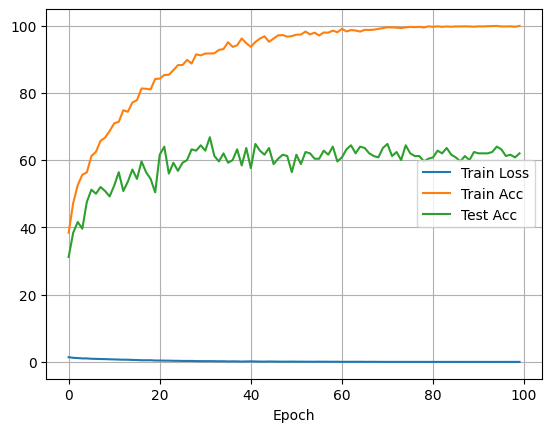

In [6]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["train_acc"], label="Train Acc")
plt.plot(history["test_acc"], label="Test Acc")

plt.xlabel("Epoch")
plt.legend()
plt.grid()

plt.show()